In [18]:
import numpy as np
import matplotlib.pyplot as plt
import pickle
import igraph as ig
from matplotlib.patches import Patch
from scipy.sparse import csr_matrix
import networkx as nx

In [19]:
def igraph_from_sparse(M, directed=False, weighted=True):
    """
    Build an igraph Graph from a SciPy sparse matrix.

    Parameters
    ----------
    M : scipy.sparse matrix (CSR/CSC/COO)
        Adjacency or weighted adjacency matrix.
    directed : bool
        Whether the graph is directed.
    weighted : bool
        Whether to store values as edge weights.

    Returns
    -------
    ig.Graph
    """
    M = M.tocoo()

    edges = list(zip(M.row.tolist(), M.col.tolist()))
    g = ig.Graph(edges=edges, directed=directed)

    if weighted:
        g.es["weight"] = M.data.tolist()

    return g


# Community preprocessing
def nx_to_igraph(G: nx.Graph, weight: str | None = "weight") -> ig.Graph:
    """
    Convert a NetworkX graph to an iGraph graph.
    
    Parameters
    ----------
    G : nx.Graph or nx.DiGraph
        Your NetworkX graph.
    weight : str or None, optional
        Name of the edge attribute to treat as weight.
        If None, graph is treated as unweighted.

    Returns
    -------
    ig.Graph
        An iGraph object with:
        - g.vs['name'] = node labels
        - g.es['weight'] = weights (if provided)
    """
    # 1) Keep original node labels
    nodes = list(G.nodes())
    idx_map = {node: i for i, node in enumerate(nodes)}

    # 2) Convert edges
    edges = [(idx_map[u], idx_map[v]) for u, v in G.edges()]

    # 3) Initialize iGraph
    g_ig = ig.Graph(edges=edges, directed=G.is_directed())
    g_ig.vs["name"] = nodes

    # 4) Add weights if available
    if weight is not None:
        # Extract weights or default to 1.0
        weights = [G[u][v].get(weight) for u, v in G.edges()]
        g_ig.es["weight"] = weights

    return g_ig

In [20]:
def knn_from_similarity(S: csr_matrix, k: int) -> csr_matrix:
    S = S.tocsr()
    rows, cols, data = [], [], []

    for i in range(S.shape[0]):
        start, end = S.indptr[i], S.indptr[i + 1]
        row_data = S.data[start:end]
        row_cols = S.indices[start:end]

        if len(row_data) > k:
            idx = np.argpartition(row_data, -k)[-k:]
            rows.extend([i] * k)
            cols.extend(row_cols[idx])
            data.extend(row_data[idx])
        else:
            rows.extend([i] * len(row_data))
            cols.extend(row_cols)
            data.extend(row_data)

    return csr_matrix((data, (rows, cols)), shape=S.shape)

In [21]:
with open(f"../output/msigdb_adjacency_matrix.pkl", "rb") as f:
    msigdb_adjacency_matrix = pickle.load(f)

In [22]:
msigdb_similarity_matrix_filtered = knn_from_similarity(msigdb_adjacency_matrix,150)
msigdb_similarity_matrix_filtered = msigdb_similarity_matrix_filtered.minimum(msigdb_similarity_matrix_filtered.T)

In [23]:
msigdb_distance_matrix_filtered = msigdb_similarity_matrix_filtered.copy()
msigdb_distance_matrix_filtered.data = 1.0 / msigdb_distance_matrix_filtered.data

In [24]:
msigdb_similarity_igraph = igraph_from_sparse(msigdb_similarity_matrix_filtered)
msigdb_distance_igraph = igraph_from_sparse(msigdb_distance_matrix_filtered)
msigdb_similarity_nxgraph = nx.from_scipy_sparse_array(msigdb_similarity_matrix_filtered)
msigdb_distance_nxgraph = nx.from_scipy_sparse_array(msigdb_distance_matrix_filtered)

In [25]:
def layer_comparison_bar_plot(
    ax,
    dgidb_scores,
    non_dgidb_scores,
    centrality,
    agg="mean"
):
    if agg == "mean":
        vals = [
            np.mean(dgidb_scores),
            np.mean(non_dgidb_scores)
        ]
    elif agg == "median":
        vals = [
            np.median(dgidb_scores),
            np.median(non_dgidb_scores)
        ]
    else:
        raise ValueError("agg must be 'mean' or 'median'")

    sems = [
        np.std(dgidb_scores, ddof=1) / np.sqrt(len(dgidb_scores)),
        np.std(non_dgidb_scores, ddof=1) / np.sqrt(len(non_dgidb_scores))
    ]

    ax.bar(
        ["DGIDB", "Non-DGIDB"],
        vals,
        yerr=sems,
        capsize=5
    )

    ax.set_ylabel(f"{agg} {centrality}")
    ax.set_title(f"{centrality}")


In [30]:
def dgidb_centrality(centrality):
    if (centrality == "eigenvector"):
        score = msigdb_similarity_igraph.eigenvector_centrality(weights="weight")
    # elif (centrality == "closeness"):
    #     score = msigdb_distance_igraph.closeness(weights="weight")
    elif (centrality == "degree"):
        score = msigdb_similarity_igraph.strength(weights="weight")
    elif (centrality == "pagerank"):
        score = msigdb_similarity_igraph.pagerank(weights="weight")
    elif (centrality == "betweenness"):
        score = msigdb_distance_igraph.betweenness(weights="weight", cutoff = 400)
    

    
    return score
    

In [27]:
def split_score(score, index):
    dgidb_scores = [score[i] for i in index]
    other_scores = [score[i] for i in range(len(score)) if i not in index]
    return dgidb_scores,other_scores

In [28]:
dgidb_score_dict, other_score_dict = {},{}

In [31]:
ec_scores = dgidb_centrality("eigenvector")
strength_scores = dgidb_centrality("degree")
pr_scores = dgidb_centrality("pagerank")
bt_scores = dgidb_centrality("betweenness")

In [32]:
scores = {}
scores["degree"] = strength_scores
scores["pagerank"] = pr_scores
scores["betweenness"] = bt_scores

In [33]:
disease_list = ["BIPOLAR","BREASTCANCER","LEUKEMIA","SCHIZOPHRENIA"]
disease_list_title = ["Bipolar Disorder", "Breast Cancer", "Leukemia", "Schizophrenia"]

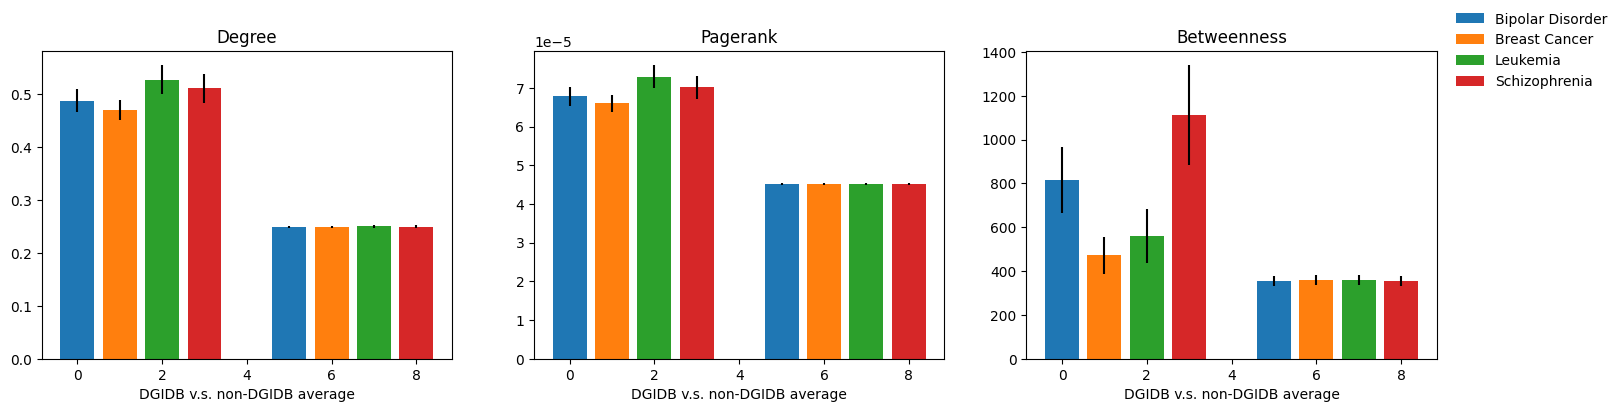

In [34]:
centralities = ["degree", "pagerank", "betweenness"]

fig, axes = plt.subplots(1, 3, figsize=(18, 4))

for i,cent in enumerate(centralities):
    ax = axes[i]
    ax.set_title(cent.capitalize())
    
    bar1 = []
    bar2 = []
    sems1 = []
    sems2 = []
    
    for d in disease_list:
        with open(f"../output/{d}/dgidb_index_in_msigdb.pkl", "rb") as f:
            dgidb_index_in_msigdb = pickle.load(f)
        
        dgidb_scores,non_dgidb_scores = split_score(scores[cent],dgidb_index_in_msigdb)
        
        bar1.append(np.mean(dgidb_scores))
        bar2.append(np.mean(non_dgidb_scores))

        sems1.append(np.std(dgidb_scores, ddof=1) / np.sqrt(len(dgidb_scores))),
        sems2.append(np.std(non_dgidb_scores, ddof=1) / np.sqrt(len(non_dgidb_scores)))
    
    # plot axes labels
    ax.set_xlabel("DGIDB v.s. non-DGIDB average")
    
    # Bar positions
    bar_width = 0.8
    inner_spacing = 1.0          # spacing inside group
    group_gap = 5              # gap between groups

    # x positions
    x = np.arange(len(bar1)) * inner_spacing
    x1 = x
    x2 = x + group_gap
    
    colors = plt.get_cmap("tab10")(range(len(disease_list)))
    
    
    # Plot group 1
    for i in range(len(disease_list)):
        ax.bar(x1[i], bar1[i],yerr = sems1[i], color=colors[i])

    # Plot group 2 (same colors by index)
    for i in range(len(disease_list)):
        ax.bar(x2[i], bar2[i],yerr = sems2[i], color=colors[i])

legend_handles = [
    Patch(facecolor=colors[i], label=disease_list_title[i])
    for i in range(len(disease_list))
]
 
fig.legend(
    handles=legend_handles,
    loc="upper right",
    ncol=1,
    frameon=False
)

plt.show()
